# Machine Learning Lab: Decision Tree vs. K-Nearest Neighbors (KNN)

This notebook implements, visualizes, and rigorously evaluates two fundamental supervised machine learning classification algorithms:
1. **Decision Tree Classifier** (Greedy recursive partitioner using Information Gain & Entropy)
2. **K-Nearest Neighbors (KNN) Classifier** (Instance-based lazy learner using distance metrics)

---
### Dataset Choice: Breast Cancer Wisconsin Diagnostic Dataset
- **Why this dataset?**:
  - 569 instances, 30 continuous real-valued features computed from fine-needle aspirate (FNA) images of breast masses.
  - Binary diagnostic classification: **Malignant (0)** vs. **Benign (1)**.
  - **Ideal for Decision Trees**: Complex continuous feature thresholds allow visual inspection of hierarchical splitting rules without trivial 1-feature shortcuts.
  - **Ideal for KNN**: Continuous multi-dimensional space demonstrates the critical importance of feature normalization/standardization ($z$-score scaling) and neighborhood distance calculations.


## 1. Setup & Environment Imports
Importing necessary libraries: numerical computation (`numpy`), tabular data handling (`pandas`), data visualization (`matplotlib`, `seaborn`), and modeling utilities (`scikit-learn`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    zero_one_loss
)

# Set consistent plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Dependencies successfully imported.")


Dependencies successfully imported.


## 2. Dataset Loading & Minimal Preprocessing

We load the dataset directly via `sklearn.datasets.load_breast_cancer()`. To avoid unnecessary clutter, only essential preprocessing steps are applied:
1. Convert to structured feature matrix $X$ and target vector $y$.
2. Inspect target class distribution to ensure balance.
3. Perform a **Stratified Train-Test Split** (75% train / 25% test) with a fixed seed (`random_state=42`).
4. Apply **Standard Scaling** ($z = \frac{x - \mu}{\sigma}$) fit strictly on training data and applied to both train/test sets for KNN.


In [2]:
# Load the raw dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name='diagnosis')
target_names = cancer.target_names  # ['malignant', 'benign']

print(f"Dataset Shape: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Target Classes: {dict(enumerate(target_names))}")
print(f"Class Distribution:\n{y.value_counts(normalize=True).rename(index=dict(enumerate(target_names))) * 100}\n")
X.head(3)


Dataset Shape: 569 samples, 30 features
Target Classes: {0: np.str_('malignant'), 1: np.str_('benign')}
Class Distribution:
diagnosis
benign       62.741652
malignant    37.258348
Name: proportion, dtype: float64



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [3]:
# Perform Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

# Feature Scaling: Essential for distance-based algorithms (KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for clean indexing
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaling complete: Mean ~ 0, Variance ~ 1 on training set.")


Training set: 426 samples
Testing set:  143 samples
Scaling complete: Mean ~ 0, Variance ~ 1 on training set.


## 3. Decision Tree Classification

### Mathematical Formulation of Node Splitting Criteria

A Decision Tree recursively splits the input feature space into axis-aligned partitions. At each node, the feature $A$ and threshold $\theta$ are chosen to maximize the reduction in impurity (Information Gain).

#### 1. Entropy
Entropy measures the degree of uncertainty or impurity in a sample set $S$ with $c$ discrete classes:

$$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

where $p_i$ is the empirical probability of class $i$ in dataset $S$. For binary classification:
$$H(S) = - p_0 \log_2(p_0) - p_1 \log_2(p_1)$$
- If all instances belong to the same class: $H(S) = 0$ (maximum purity).
- If classes are evenly split ($p_0 = p_1 = 0.5$): $H(S) = 1$ (maximum impurity).

#### 2. Information Gain ($IG$)
Information Gain measures the expected reduction in entropy achieved by partitioning dataset $S$ based on attribute $A$:

$$IG(S, A) = H(S) - \sum_{v \in \text{Values}(A)} \frac{|S_v|}{|S|} H(S_v)$$

where $S_v$ is the subset of $S$ for which attribute $A$ has value/partition $v$, and $\frac{|S_v|}{|S|}$ is the weight fraction of that subset.

#### 3. Alternative Criterion: Gini Impurity
The Gini Index measures the probability of misclassifying a randomly chosen element from the set if it were randomly labeled according to the class distribution:

$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$

- Pure node: $Gini(S) = 0$.
- Binary evenly split: $Gini(S) = 1 - (0.5^2 + 0.5^2) = 0.5$.


### 3.1 Decision Tree Training & Tree Graph Visualization
We train a `DecisionTreeClassifier` using `criterion='entropy'`. We set `max_depth=4` for the primary model to ensure the graphical decision tree is interpretable and clearly visible.


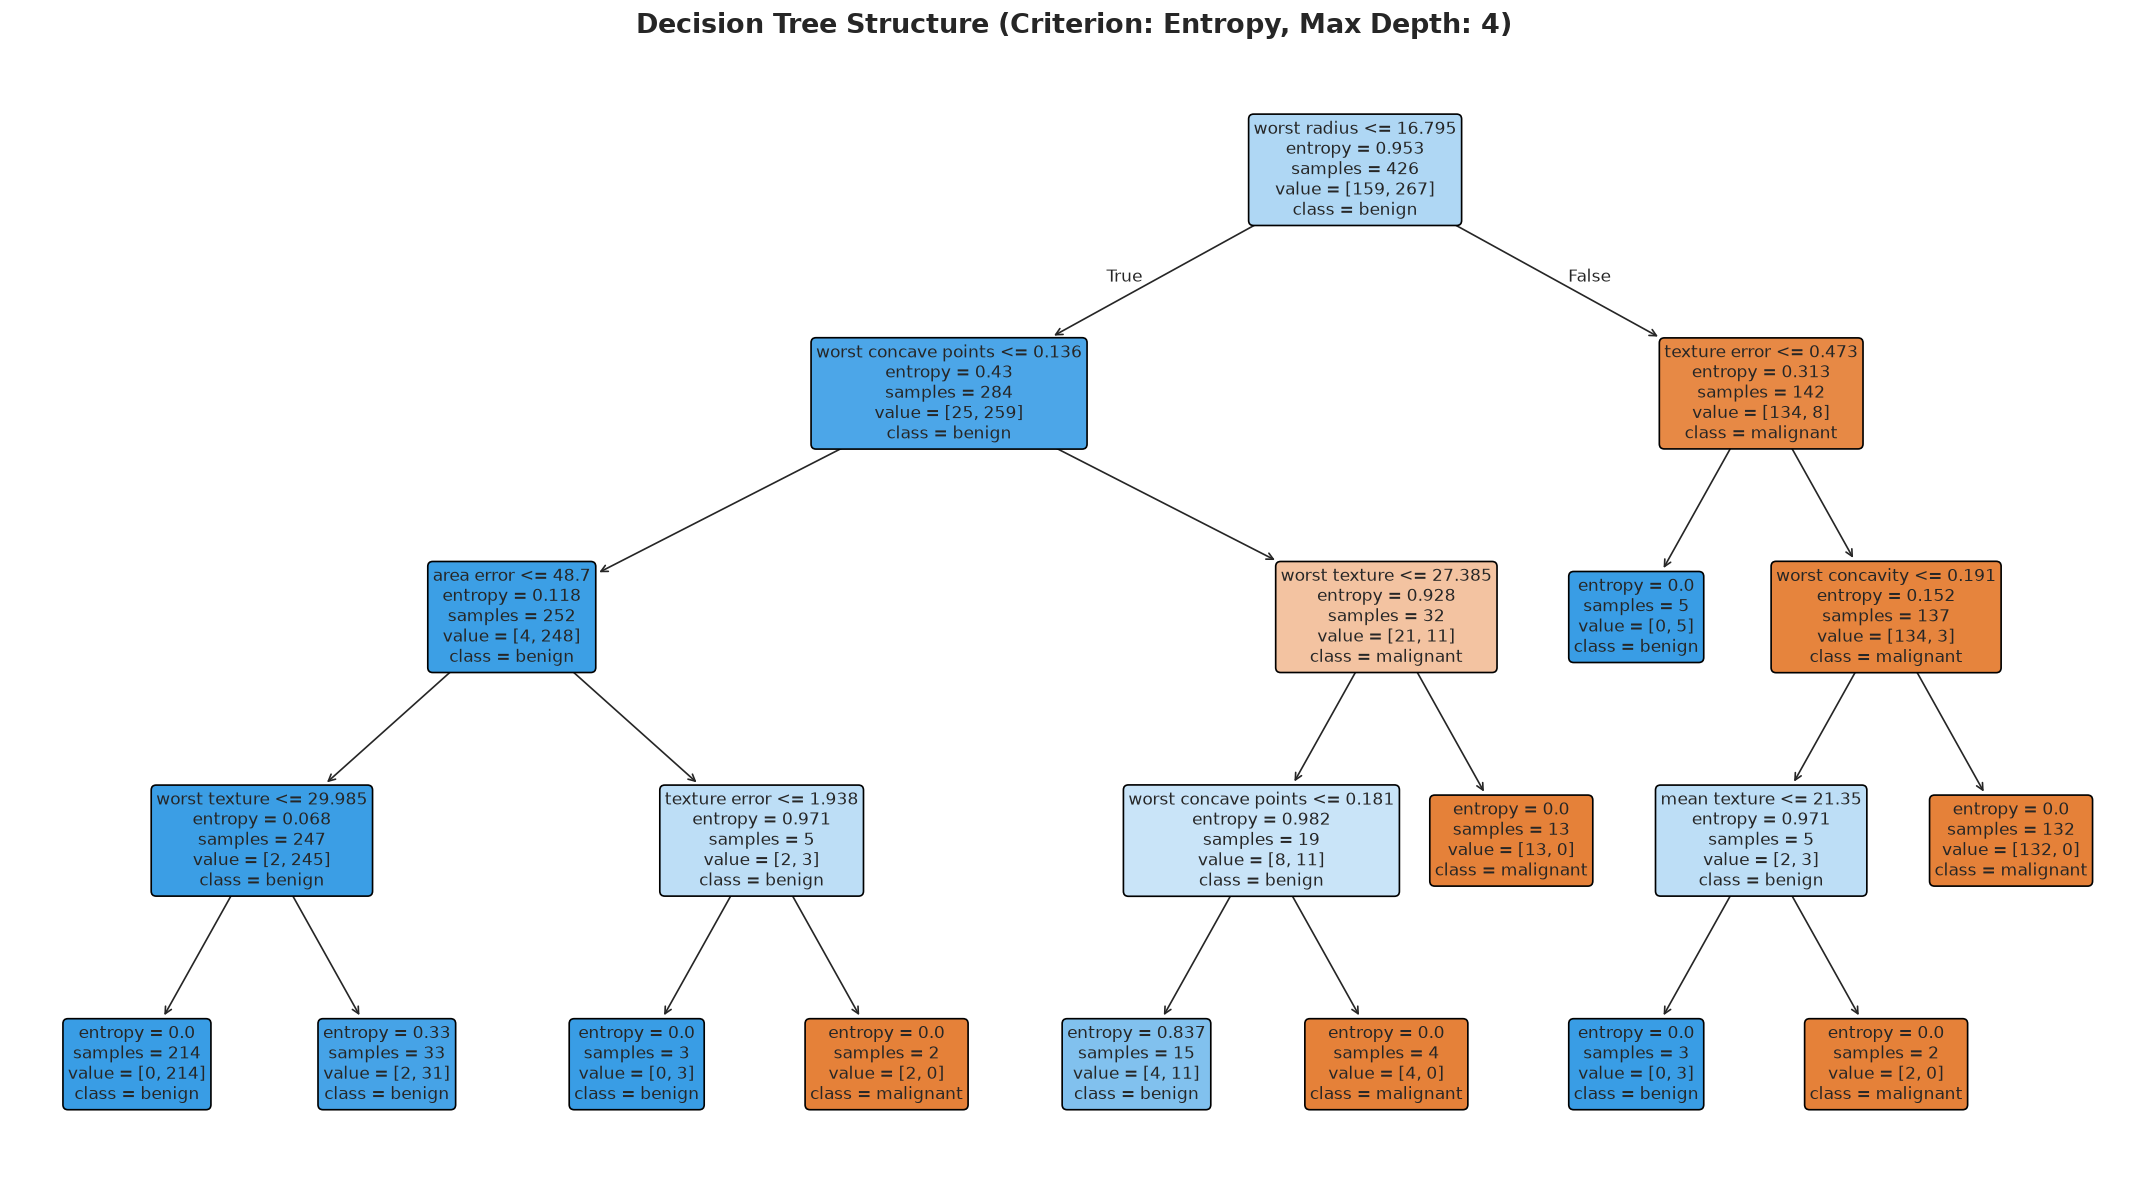

In [4]:
# Train Decision Tree with Entropy criterion
dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

# Visualize the Decision Tree
fig, ax = plt.subplots(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=cancer.feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
plt.title("Decision Tree Structure (Criterion: Entropy, Max Depth: 4)", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


### 3.2 Decision Tree Evaluation & Confusion Matrix
Evaluating performance on unseen test data with Confusion Matrix and standard classification metrics:
- $\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$
- $\text{Precision} = \frac{TP}{TP + FP}$
- $\text{Recall} = \frac{TP}{TP + FN}$
- $\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$
- $\text{Misclassification Error} = 1 - \text{Accuracy} = \frac{FP + FN}{N}$


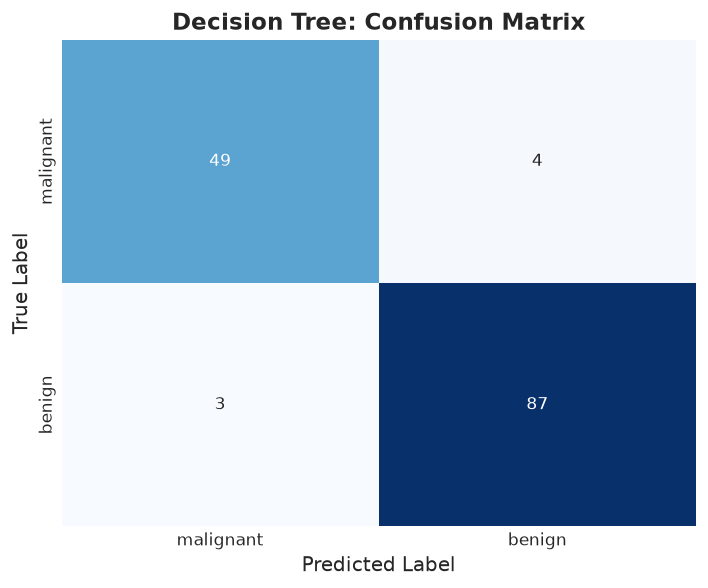

=== Decision Tree Evaluation Metrics ===
Accuracy:                 0.9510 (95.10%)
Precision (Benign):       0.9560
Recall (Benign):          0.9667
F1-Score:                 0.9613
Misclassification Error:  0.0490 (4.90%)

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.94      0.92      0.93        53
      benign       0.96      0.97      0.96        90

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143



In [5]:
y_pred_dt = dt_model.predict(X_test)

# Calculate metrics
dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_error = zero_one_loss(y_test, y_pred_dt)

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False,
    ax=ax
)
ax.set_title("Decision Tree: Confusion Matrix", fontweight='bold')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"=== Decision Tree Evaluation Metrics ===")
print(f"Accuracy:                 {dt_acc:.4f} ({dt_acc*100:.2f}%)")
print(f"Precision (Benign):       {dt_prec:.4f}")
print(f"Recall (Benign):          {dt_rec:.4f}")
print(f"F1-Score:                 {dt_f1:.4f}")
print(f"Misclassification Error:  {dt_error:.4f} ({dt_error*100:.2f}%)\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=target_names))


### 3.3 Decision Tree Parametric Error Curve: Error Rate vs. `max_depth`
To analyze underfitting (high bias when tree depth is too shallow) and overfitting (high variance when depth is unrestricted), we evaluate the misclassification error rate on both training and testing sets across tree depths from 1 to 15.


<>:24: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:24: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
/tmp/ipykernel_15028/2967368564.py:24: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  plt.xlabel("Max Depth ($max\_depth$)")


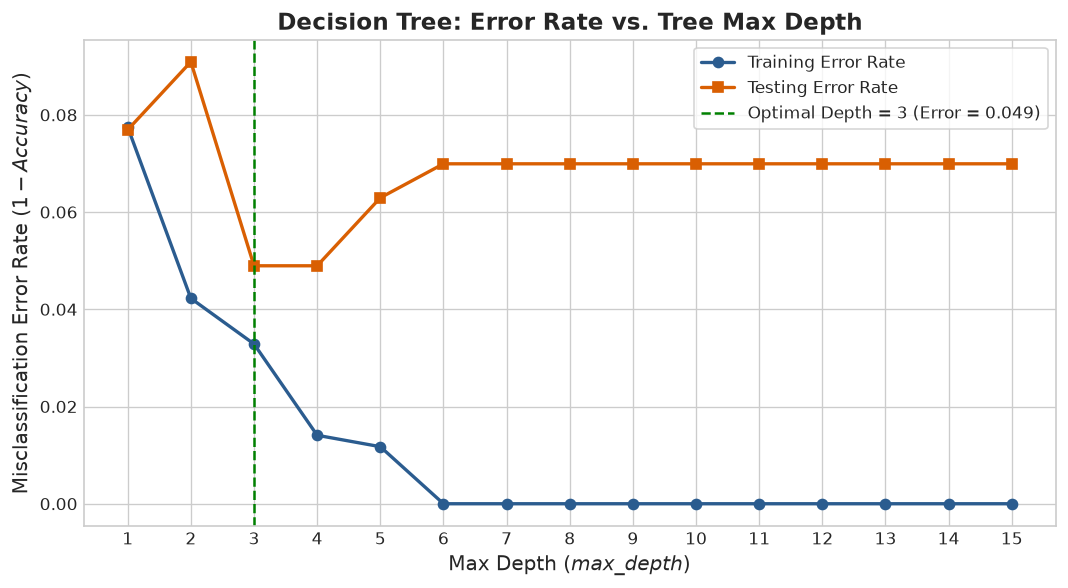

Optimal Decision Tree Max Depth: 3 with Test Error: 0.0490 (Accuracy: 0.9510)


In [6]:
depths = list(range(1, 16))
dt_train_errors = []
dt_test_errors = []

for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    
    train_err = 1.0 - accuracy_score(y_train, clf.predict(X_train))
    test_err = 1.0 - accuracy_score(y_test, clf.predict(X_test))
    
    dt_train_errors.append(train_err)
    dt_test_errors.append(test_err)

best_depth = depths[np.argmin(dt_test_errors)]
min_dt_error = min(dt_test_errors)

plt.figure(figsize=(9, 5))
plt.plot(depths, dt_train_errors, marker='o', label='Training Error Rate', color='#2b5c8f', linewidth=2)
plt.plot(depths, dt_test_errors, marker='s', label='Testing Error Rate', color='#d95f02', linewidth=2)
plt.axvline(x=best_depth, color='green', linestyle='--', label=f'Optimal Depth = {best_depth} (Error = {min_dt_error:.3f})')

plt.title("Decision Tree: Error Rate vs. Tree Max Depth", fontweight='bold')
plt.xlabel("Max Depth ($max\_depth$)")
plt.ylabel("Misclassification Error Rate ($1 - Accuracy$)")
plt.xticks(depths)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal Decision Tree Max Depth: {best_depth} with Test Error: {min_dt_error:.4f} (Accuracy: {1-min_dt_error:.4f})")


## 4. K-Nearest Neighbors (KNN) Classification

### Mathematical Formulation of Distance Metrics & Decision Rule

K-Nearest Neighbors is a non-parametric, instance-based lazy learning algorithm. Given a query instance $x$, the algorithm finds the $K$ closest training instances $\{x^{(1)}, x^{(2)}, \dots, x^{(K)}\}$ based on a distance metric in feature space $\mathbb{R}^n$.

#### 1. Euclidean Distance ($L_2$ Norm)
The straight-line geometric distance between two points $p = (p_1, \dots, p_n)$ and $q = (q_1, \dots, q_n)$:

$$d_{\text{Euclidean}}(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2} = \|p - q\|_2$$

#### 2. Manhattan Distance ($L_1$ Norm)
The sum of absolute differences along coordinate axes (taxicab distance):

$$d_{\text{Manhattan}}(p, q) = \sum_{i=1}^{n} |p_i - q_i| = \|p - q\|_1$$

#### 3. Minkowski Distance ($L_p$ Metric Generalization)
The generalized distance metric parameterized by order $p$:

$$d_{\text{Minkowski}}(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{\frac{1}{p}}$$

- For $p = 1$: reduces to Manhattan distance.
- For $p = 2$: reduces to Euclidean distance.

#### 4. Majority Voting Decision Rule
The predicted class label $\hat{y}$ for query instance $x$ is determined by plurality vote among its $K$ nearest neighbors $N_K(x)$:

$$\hat{y} = \arg\max_{c \in C} \sum_{i \in N_K(x)} I(y^{(i)} = c)$$

where $I(\cdot)$ is the indicator function ($1$ if condition is met, $0$ otherwise).

#### 5. Role of Feature Standardization
Because distance metrics directly aggregate squared or absolute differences across dimensions, features with large numerical magnitudes (e.g., `mean area` $\sim 1000$) would completely dominate features with small numerical values (e.g., `mean smoothness` $\sim 0.1$). Standardizing features to zero mean and unit variance ($z = \frac{x - \mu}{\sigma}$) ensures isotropic metric weighting.


### 4.1 KNN Model Training & Confusion Matrix
We train a `KNeighborsClassifier` using Euclidean distance (`metric='minkowski', p=2`) on standardized features.


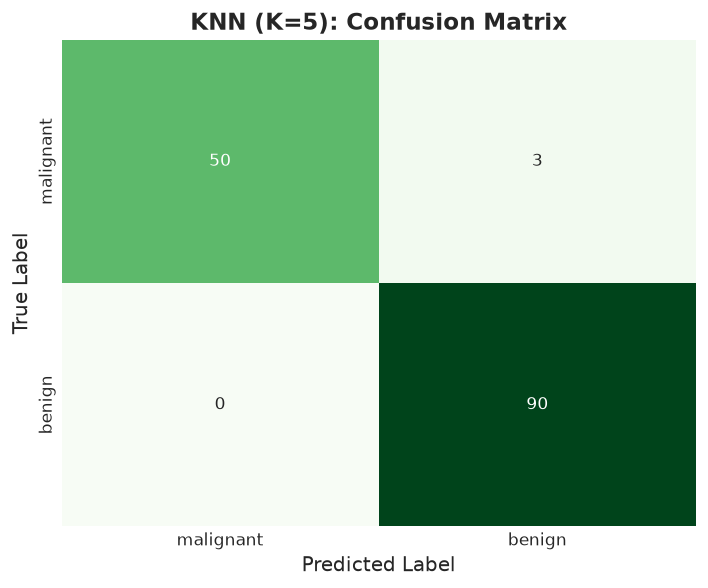

=== KNN (K=5) Evaluation Metrics ===
Accuracy:                 0.9790 (97.90%)
Precision (Benign):       0.9677
Recall (Benign):          1.0000
F1-Score:                 0.9836
Misclassification Error:  0.0210 (2.10%)

Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



In [7]:
# Train initial KNN model with K=5
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

# Calculate metrics
knn_acc = accuracy_score(y_test, y_pred_knn)
knn_prec = precision_score(y_test, y_pred_knn)
knn_rec = recall_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)
knn_error = zero_one_loss(y_test, y_pred_knn)

# Plot Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=False,
    ax=ax
)
ax.set_title("KNN (K=5): Confusion Matrix", fontweight='bold')
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

print(f"=== KNN (K=5) Evaluation Metrics ===")
print(f"Accuracy:                 {knn_acc:.4f} ({knn_acc*100:.2f}%)")
print(f"Precision (Benign):       {knn_prec:.4f}")
print(f"Recall (Benign):          {knn_rec:.4f}")
print(f"F1-Score:                 {knn_f1:.4f}")
print(f"Misclassification Error:  {knn_error:.4f} ({knn_error*100:.2f}%)\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=target_names))


### 4.2 KNN Parametric Error Curve: Error Rate vs. $K$
To select the optimal number of neighbors, we evaluate the misclassification error rate for $K$ ranging from 1 to 30.
- When $K=1$, the model memorizes the training data (zero training error) but has high variance and sensitivity to noise.
- When $K$ becomes too large, the neighborhood includes distant points from other classes, leading to oversmoothing and high bias.


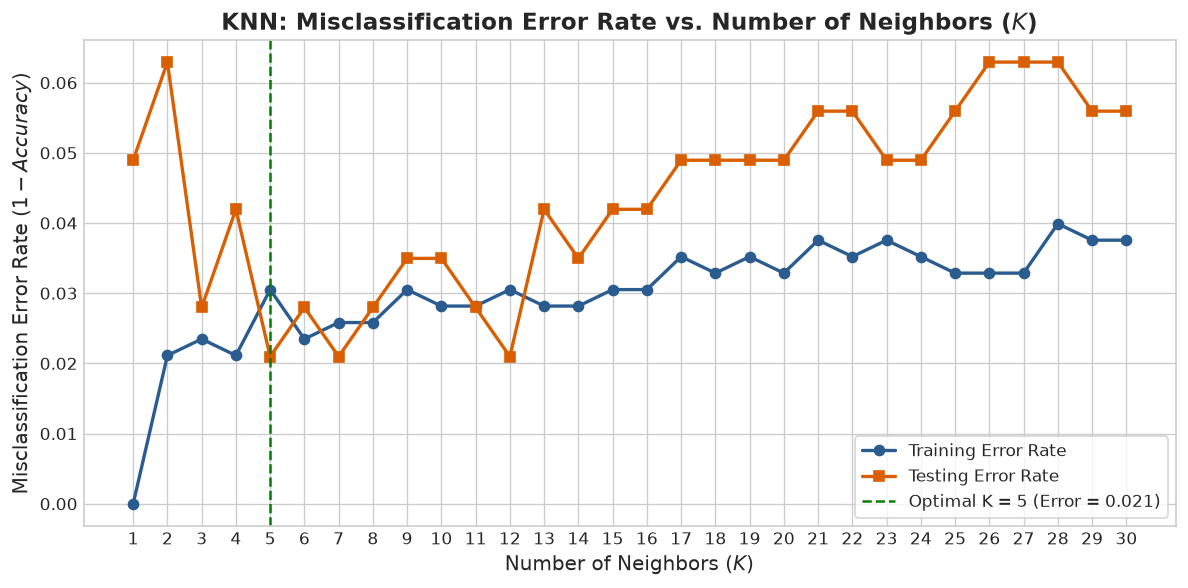

Optimal KNN Neighbor Count: K = 5 with Test Error: 0.0210 (Accuracy: 0.9790)


In [8]:
k_range = list(range(1, 31))
knn_train_errors = []
knn_test_errors = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    knn.fit(X_train_scaled, y_train)
    
    train_err = 1.0 - accuracy_score(y_train, knn.predict(X_train_scaled))
    test_err = 1.0 - accuracy_score(y_test, knn.predict(X_test_scaled))
    
    knn_train_errors.append(train_err)
    knn_test_errors.append(test_err)

best_k = k_range[np.argmin(knn_test_errors)]
min_knn_error = min(knn_test_errors)

plt.figure(figsize=(10, 5))
plt.plot(k_range, knn_train_errors, marker='o', label='Training Error Rate', color='#2b5c8f', linewidth=2)
plt.plot(k_range, knn_test_errors, marker='s', label='Testing Error Rate', color='#d95f02', linewidth=2)
plt.axvline(x=best_k, color='green', linestyle='--', label=f'Optimal K = {best_k} (Error = {min_knn_error:.3f})')

plt.title("KNN: Misclassification Error Rate vs. Number of Neighbors ($K$)", fontweight='bold')
plt.xlabel("Number of Neighbors ($K$)")
plt.ylabel("Misclassification Error Rate ($1 - Accuracy$)")
plt.xticks(k_range)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

print(f"Optimal KNN Neighbor Count: K = {best_k} with Test Error: {min_knn_error:.4f} (Accuracy: {1-min_knn_error:.4f})")


## 5. Model Comparison & Synthesis

### Performance Summary Table
Below is a consolidated side-by-side comparison of the Decision Tree Classifier and K-Nearest Neighbors Classifier on the Breast Cancer diagnostic test set.


In [9]:
# Refit best models
best_dt = DecisionTreeClassifier(criterion='entropy', max_depth=best_depth, random_state=42).fit(X_train, y_train)
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric='minkowski', p=2).fit(X_train_scaled, y_train)

y_pred_best_dt = best_dt.predict(X_test)
y_pred_best_knn = best_knn.predict(X_test_scaled)

comparison_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Misclassification Error',
        'Precision (Benign)',
        'Recall (Benign)',
        'F1-Score (Benign)'
    ],
    f'Decision Tree (depth={best_depth})': [
        f"{accuracy_score(y_test, y_pred_best_dt):.4f}",
        f"{zero_one_loss(y_test, y_pred_best_dt):.4f}",
        f"{precision_score(y_test, y_pred_best_dt):.4f}",
        f"{recall_score(y_test, y_pred_best_dt):.4f}",
        f"{f1_score(y_test, y_pred_best_dt):.4f}"
    ],
    f'KNN (K={best_k})': [
        f"{accuracy_score(y_test, y_pred_best_knn):.4f}",
        f"{zero_one_loss(y_test, y_pred_best_knn):.4f}",
        f"{precision_score(y_test, y_pred_best_knn):.4f}",
        f"{recall_score(y_test, y_pred_best_knn):.4f}",
        f"{f1_score(y_test, y_pred_best_knn):.4f}"
    ]
})

# Display formatted table
from IPython.display import display
print("=== Summary Comparison Table ===")
print(comparison_df.to_string(index=False))
display(comparison_df.style.set_caption("Comparative Performance of Decision Tree vs. KNN").hide(axis='index'))


=== Summary Comparison Table ===
                 Metric Decision Tree (depth=3) KNN (K=5)
               Accuracy                  0.9510    0.9790
Misclassification Error                  0.0490    0.0210
     Precision (Benign)                  0.9462    0.9677
        Recall (Benign)                  0.9778    1.0000
      F1-Score (Benign)                  0.9617    0.9836


Metric,Decision Tree (depth=3),KNN (K=5)
Accuracy,0.9510,0.9790
Misclassification Error,0.0490,0.0210
Precision (Benign),0.9462,0.9677
Recall (Benign),0.9778,1.0000
F1-Score (Benign),0.9617,0.9836


### Key Takeaways & Conceptual Comparison

| Dimension | Decision Tree | K-Nearest Neighbors (KNN) |
| :--- | :--- | :--- |
| **Learning Paradigm** | Eager learner (computes explicit tree rules during training) | Lazy learner (stores training points, computes distances at query time) |
| **Feature Scale Sensitivity** | **Scale invariant** (splits on individual thresholds monotonically) | **Highly sensitive to scale** (requires standardization) |
| **Interpretability** | **High** (graphical tree can be read by human experts as logic rules) | **Moderate/Low** (explains prediction by listing closest neighbors) |
| **Prediction Speed** | $O(\text{depth})$ - very fast logarithmic path | $O(N \cdot d)$ - slower on large datasets unless using KD-Tree/BallTree |
| **Decision Boundary** | Orthogonal, axis-aligned hyperplanes | Smooth, non-linear local neighborhood boundaries |
